In [7]:
# importing and unzipping our snake data (images in .zip)

import zipfile
import os

zip_path = 'snake_data.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./snake_data')

# folder structure
for root, dirs, files in os.walk("./snake_data", topdown=True):
    print(root)

./snake_data
./snake_data/snake_data
./snake_data/snake_data/snake_data
./snake_data/snake_data/snake_data/train
./snake_data/snake_data/snake_data/train/non_venemous
./snake_data/snake_data/snake_data/train/venemous
./snake_data/snake_data/snake_data/test
./snake_data/snake_data/snake_data/test/non_venemous
./snake_data/snake_data/snake_data/test/venemous
./snake_data/__MACOSX
./snake_data/__MACOSX/snake_data
./snake_data/__MACOSX/snake_data/snake_data
./snake_data/__MACOSX/snake_data/snake_data/train
./snake_data/__MACOSX/snake_data/snake_data/train/non_venemous
./snake_data/__MACOSX/snake_data/snake_data/test
./snake_data/__MACOSX/snake_data/snake_data/test/non_venemous
./snake_data/__MACOSX/snake_data/snake_data/test/venemous


In [10]:
import shutil
import os

# moving the "correct" nested folder up one level
nested_path = "./snake_data/snake_data/snake_data"
flat_path = "./snake_data_fixed"

shutil.move(nested_path, flat_path)

# makes directory nesting so image folders are in a clean and more accessible location for loading

Error: Destination path './snake_data_fixed/snake_data' already exists

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# defining our paths
train_dir = './snake_data_fixed/train'
test_dir = './snake_data_fixed/test'

# creating the data generators
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# above, we've loaded and labeled images from folders while scaling pixel values for model training

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# loads the MobileNetV2 model without the top layers (we’ll add our own output layers
base_model = MobileNetV2(include_top=False, input_shape=(128, 128, 3), weights='imagenet')
base_model.trainable = False  # freezes the MobileNetV2 base model so pretrained weights don’t change during training

# builds our final model by new layers on top of the frozen base one
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # used forbinary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# summary: builds and compiles a CNN using MobileNetV2 base to classify venomous verrsus non-venomous snakes

2025-04-15 11:27:39.629997: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22169 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:41:00.0, compute capability: 8.6


9406464/9406464 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Func  (None, 4, 4, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                           

In [5]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

# trains the model using the training data for 10 full passes, aka epochs, while checking accuracy on test data each time

Epoch 1/10


2025-04-15 11:28:05.351638: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8904
2025-04-15 11:28:06.399006: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:625] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-04-15 11:28:06.835933: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f0b456e8df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-15 11:28:06.835981: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-04-15 11:28:06.939476: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-15 11:28:07.651409: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p

92/92 [==============================] - 31s 284ms/step - loss: 0.1621 - accuracy: 0.9367 - val_loss: 0.1043 - val_accuracy: 0.9630
Epoch 2/10
92/92 [==============================] - 18s 196ms/step - loss: 0.0767 - accuracy: 0.9758 - val_loss: 0.1161 - val_accuracy: 0.9597
Epoch 3/10
92/92 [==============================] - 10s 109ms/step - loss: 0.0555 - accuracy: 0.9806 - val_loss: 0.1484 - val_accuracy: 0.9452
Epoch 4/10
92/92 [==============================] - 9s 98ms/step - loss: 0.0359 - accuracy: 0.9884 - val_loss: 0.1183 - val_accuracy: 0.9605
Epoch 5/10
92/92 [==============================] - 8s 85ms/step - loss: 0.0306 - accuracy: 0.9891 - val_loss: 0.1224 - val_accuracy: 0.9573
Epoch 6/10
92/92 [==============================] - 8s 84ms/step - loss: 0.0178 - accuracy: 0.9949 - val_loss: 0.1374 - val_accuracy: 0.9589
Epoch 7/10
92/92 [==============================] - 7s 79ms/step - loss: 0.0164 - accuracy: 0.9952 - val_loss: 0.1383 - val_accuracy: 0.9646
Epoch 8/10
92/92 [

39/39 [==============================] - 3s 58ms/step
Classification Report:

              precision    recall  f1-score   support

non_venemous       0.98      0.95      0.97       776
    venemous       0.93      0.97      0.95       466

    accuracy                           0.96      1242
   macro avg       0.95      0.96      0.96      1242
weighted avg       0.96      0.96      0.96      1242



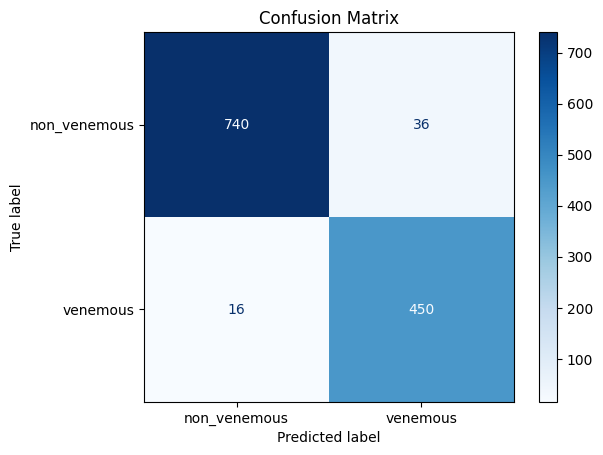

Accuracy: 0.9581
Precision: 0.9259
Recall: 0.9657
F1 Score: 0.9454


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# get true labels from the test generator
y_true = test_data.classes

# predict probabilities from the model
y_pred_probs = model.predict(test_data)

# convert probabilities to binary labels (as we use binary classification)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# specific evaluation metrics defined in our MI2
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(test_data.class_indices.keys())

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))

# showing our confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
